In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models 


In [2]:
mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

In [4]:
X=mnist.data
y=mnist.target.astype(int)

In [8]:
print(X.shape)
y.shape

(70000, 784)


(70000,)

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.22,random_state=42)

In [11]:
X_train=X_train/255.0
X_test=X_test/255.0

In [12]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

In [13]:
print(X_train.shape)
print(X_test.shape)

(54600, 28, 28, 1)
(15400, 28, 28, 1)


In [15]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
    
])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,011,466 (3.86 MB)

 Trainable params: 1,011,466 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [20]:
history=model.fit(X_train,y_train,epochs=10,batch_size=64,validation_data=(
    X_test,y_test
))

Epoch 1/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.8605 - loss: 0.4526 - val_accuracy: 0.9459 - val_loss: 0.1732
Epoch 2/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - accuracy: 0.9331 - loss: 0.2260 - val_accuracy: 0.9581 - val_loss: 0.1339
Epoch 3/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 105s 95ms/step - accuracy: 0.9421 - loss: 0.1920 - val_accuracy: 0.9634 - val_loss: 0.1230
Epoch 4/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 59s 69ms/step - accuracy: 0.9495 - loss: 0.1728 - val_accuracy: 0.9669 - val_loss: 0.1110
Epoch 5/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 78s 64ms/step - accuracy: 0.9526 - loss: 0.1584 - val_accuracy: 0.9688 - val_loss: 0.1089
Epoch 6/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 54s 63ms/step - accuracy: 0.9541 - loss: 0.1496 - val_accuracy: 0.9718 - val_loss: 0.0975
Epoch 7/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 61s 71ms/step - accuracy: 0.9569 - loss: 0.1414 - val_accuracy: 0.9731 - val_loss: 0.0933
Epoch 8/10
854/854 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.9586 - loss: 0.1349 -

In [21]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:", test_accuracy)


482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9747 - loss: 0.0836
Test Accuracy: 0.9746752977371216


In [24]:
index=10

image=X_test[index]
prediction=model.predict(image.reshape(1,28,28,1))

predicted_digit=np.argmax(prediction)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


In [25]:
print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[index])

Predicted Digit: 3
Actual Digit: 3


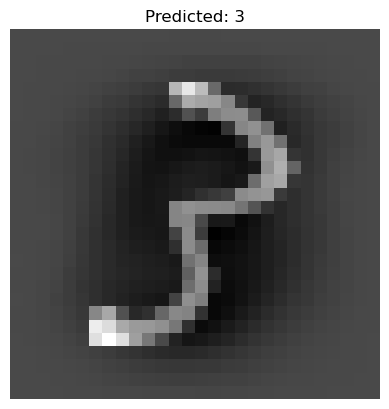

In [29]:
plt.imshow(
    image.reshape(28,28),
    cmap="gray"
)
plt.title(
    f"Predicted: {predicted_digit}"
)
plt.axis("off")
plt.show()

In [31]:
model.save("DigitRecognizer.keras")